In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
cd C:/Users/TAPAN/Desktop/Python ML/CVD-1/SPSS4/valid_HPMTR/csv

C:\Users\TAPAN\Desktop\Python ML\CVD-1\SPSS4\valid_HPMTR\csv


In [3]:
pwd

'C:\\Users\\TAPAN\\Desktop\\Python ML\\CVD-1\\SPSS4\\valid_HPMTR\\csv'

In [4]:
df = pd.read_csv('heart_statlog_cleveland_hungary_4.csv')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [6]:
df.nunique()

age                     50
sex                      2
chest pain type          4
resting bp s            67
cholesterol            222
fasting blood sugar      2
resting ecg              3
max heart rate         119
exercise angina          2
oldpeak                 53
ST slope                 4
target                   2
dtype: int64

In [7]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [6]:
#newdf = df.drop(columns = ['fasting blood sugar', 'resting ecg'])

In [6]:
data_X = df.drop('target',axis=1)
data_Y = df['target']
from sklearn.preprocessing import StandardScaler
from sklearn import neighbors, datasets, preprocessing
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, cohen_kappa_score, matthews_corrcoef, jaccard_score
#from sklearn.linear_model import LogisticRegression
#from sklearn.naive_bayes import GaussianNB
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.ensemble import GradientBoostingClassifier
#from sklearn.svm import SVM
#from sklearn.metrics import roc_curve, auc

In [8]:
#normal_data_X = (data_X - np.min(data_X)) / (np.max(data_X) - np.min(data_X))
#train_X,test_X,train_y,test_y = train_test_split(normal_data_X,data_Y,random_state=1,test_size=0.2)
#train_size_= 0.8

from fast_ml.model_development import train_valid_test_split
train_X, train_y, valid_X, valid_y, test_X, test_y = train_valid_test_split(df, target='target', train_size=0.8, valid_size=0.1, test_size=0.1)

#for data in [train_X, test_X, valid_X, valid_y, train_y, test_y]: data.reset_index(drop=True, inplace=True)
    
print(train_X.shape, train_y.shape)
print(valid_X.shape, valid_y.shape)
print(test_X.shape, test_y.shape)

(952, 11) (952,)
(119, 11) (119,)
(119, 11) (119,)


In [9]:
from sklearn.decomposition import PCA
pca=PCA().fit(train_X)
print(pca.explained_variance_ratio_)
#print(train_X.columns.values.tolist())
#print(pca.components_)

[9.08500609e-01 5.78635571e-02 2.72599480e-02 6.07253709e-03
 1.18475096e-04 6.38906011e-05 5.96767006e-05 2.03697283e-05
 1.55066332e-05 1.37219757e-05 1.17078881e-05]


In [10]:
# AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier
adb = AdaBoostClassifier(n_estimators=100, learning_rate=10, algorithm='SAMME', random_state=None)
i= 1
results=[]
#print(cm_adb)
while i <= 1:
    adb.fit(train_X, train_y)
    adb_prediction = adb.predict(test_X)
    print('AdaBoostClassifier Score : %.5f' % adb.score(test_X, test_y))
    i += 1
    cm_adb = confusion_matrix(test_y,adb_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_adb[0][0]
    result[1]=cm_adb[0][1]
    result[2]=cm_adb[1][0]
    result[3]=cm_adb[1][1]
    result[4]=adb.score(test_X, test_y)
    result[5]=precision_score(test_y, adb_prediction)
    result[6]=recall_score(test_y, adb_prediction)
    result[7]=f1_score(test_y, adb_prediction)
    result[8]=cohen_kappa_score(test_y, adb_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('ADB.csv')

AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier Score : 0.80672
AdaBoostClassifier S

In [11]:
# BaggingClassifier Classifier
from sklearn.ensemble import BaggingClassifier
bc = BaggingClassifier(max_features=9, max_samples=10, n_estimators=10)
results=[]
#print(cm_bc)
for i in range(1):
    bc.fit(train_X, train_y)
    bc_prediction = bc.predict(test_X)
    print("BaggingClassifier score: ",bc.score(test_X, test_y))
    cm_bc = confusion_matrix(test_y,bc_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_bc[0][0]
    result[1]=cm_bc[0][1]
    result[2]=cm_bc[1][0]
    result[3]=cm_bc[1][1]
    result[4]=bc.score(test_X, test_y)
    result[5]=precision_score(test_y, bc_prediction)
    result[6]=recall_score(test_y, bc_prediction)
    result[7]=f1_score(test_y, bc_prediction)
    result[8]=cohen_kappa_score(test_y, bc_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('BC.csv')

BaggingClassifier score:  0.7563025210084033


In [12]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(criterion='gini',splitter='random',max_depth=None, min_samples_leaf=2, min_samples_split=5, max_features=None)
results=[]
#print(cm_dtc)
for i in range(1):
    dtc.fit(train_X, train_y)
    dtc_prediction = dtc.predict(test_X)
    print("DecisionTreeClassifier Score : ",dtc.score(test_X, test_y))
    cm_dtc = confusion_matrix(test_y,dtc_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_dtc[0][0]
    result[1]=cm_dtc[0][1]
    result[2]=cm_dtc[1][0]
    result[3]=cm_dtc[1][1]
    result[4]=dtc.score(test_X, test_y)
    result[5]=precision_score(test_y, dtc_prediction)
    result[6]=recall_score(test_y, dtc_prediction)
    result[7]=f1_score(test_y, dtc_prediction)
    result[8]=cohen_kappa_score(test_y, dtc_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('DT.csv')

DecisionTreeClassifier Score :  0.8235294117647058


In [13]:
# ExtraTrees Classifier
from sklearn.ensemble import ExtraTreesClassifier
etc = ExtraTreesClassifier()
results=[]
#print(cm_etc)
for i in range(1):
    etc.fit(train_X, train_y)
    etc_prediction = etc.predict(test_X)
    print("ExtraTreesClassifier score: ",etc.score(test_X, test_y))
    cm_etc = confusion_matrix(test_y,etc_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_etc[0][0]
    result[1]=cm_etc[0][1]
    result[2]=cm_etc[1][0]
    result[3]=cm_etc[1][1]
    result[4]=etc.score(test_X, test_y)
    result[5]=precision_score(test_y, etc_prediction)
    result[6]=recall_score(test_y, etc_prediction)
    result[7]=f1_score(test_y, etc_prediction)
    result[8]=cohen_kappa_score(test_y, etc_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('ETC.csv')
print("Precision score: %1.4f" % precision_score(test_y, etc_prediction, average='macro'))
print("Recall score: %1.4f" % recall_score(test_y, etc_prediction, average='macro'))
print("F1 score: %1.4f" % f1_score(test_y, etc_prediction, average='macro'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, etc_prediction, average='macro'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, etc_prediction))
print("MCC score: %1.4f" % matthews_corrcoef(test_y, etc_prediction))

print("Precision score: %1.4f" % precision_score(test_y, etc_prediction, average='weighted'))
print("Recall score: %1.4f" % recall_score(test_y, etc_prediction, average='weighted'))
print("F1 score: %1.4f" % f1_score(test_y, etc_prediction, average='weighted'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, etc_prediction, average='weighted'))

ExtraTreesClassifier score:  0.9327731092436975
Precision score: 0.9332
Recall score: 0.9329
F1 score: 0.9328
Jaccard score: 0.8740
Cohen-kappa score: 0.8656
MCC score: 0.8661
Precision score: 0.9333
Recall score: 0.9328
F1 score: 0.9328
Jaccard score: 0.8740


In [14]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
results=[]
#print(cm_gb)
for i in range(1):
    gb.fit(train_X, train_y)
    gb_prediction = gb.predict(test_X)
    print("GradientBoostingClassifier score: ",gb.score(test_X, test_y))
    cm_gb = confusion_matrix(test_y,gb_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_gb[0][0]
    result[1]=cm_gb[0][1]
    result[2]=cm_gb[1][0]
    result[3]=cm_gb[1][1]
    result[4]=gb.score(test_X, test_y)
    result[5]=precision_score(test_y, gb_prediction)
    result[6]=recall_score(test_y, gb_prediction)
    result[7]=f1_score(test_y, gb_prediction)
    result[8]=cohen_kappa_score(test_y, gb_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('GB.csv')

GradientBoostingClassifier score:  0.8907563025210085


In [15]:
# Gaussian Naive bayes Classifier
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
results=[]
#print(cm_gnb)
for i in range(1):
    gnb.fit(train_X, train_y)
    gnb_prediction = gnb.predict(test_X)
    print('Gaussian Naive bayes Score: %.5f' %gnb.score(test_X, test_y))
    cm_gnb = confusion_matrix(test_y,gnb_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_gnb[0][0]
    result[1]=cm_gnb[0][1]
    result[2]=cm_gnb[1][0]
    result[3]=cm_gnb[1][1]
    result[4]=gnb.score(test_X, test_y)
    result[5]=precision_score(test_y, gnb_prediction)
    result[6]=recall_score(test_y, gnb_prediction)
    result[7]=f1_score(test_y, gnb_prediction)
    result[8]=cohen_kappa_score(test_y, gnb_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('GNB.csv')

Gaussian Naive bayes Score: 0.82353


In [16]:
# K-Nearest Neighbour Classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='ball_tree', leaf_size=30, p=2, metric='minkowski')
results=[]
#print(cm_knn)
for i in range(1):
    knn.fit(train_X, train_y)
    knn_prediction = knn.predict(test_X)
    print('K-Nearest Neighbour score : %.5f' %knn.score(test_X, test_y))
    cm_knn = confusion_matrix(test_y,knn_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_knn[0][0]
    result[1]=cm_knn[0][1]
    result[2]=cm_knn[1][0]
    result[3]=cm_knn[1][1]
    result[4]=knn.score(test_X, test_y)
    result[5]=precision_score(test_y, knn_prediction)
    result[6]=recall_score(test_y, knn_prediction)
    result[7]=f1_score(test_y, knn_prediction)
    result[8]=cohen_kappa_score(test_y, knn_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('KNN.csv')

print("Precision score: %1.4f" % precision_score(test_y, knn_prediction, average='macro'))
print("Recall score: %1.4f" % recall_score(test_y, knn_prediction, average='macro'))
print("F1 score: %1.4f" % f1_score(test_y, knn_prediction, average='macro'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, knn_prediction, average='macro'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, knn_prediction))
print("MCC score: %1.4f" % matthews_corrcoef(test_y, knn_prediction))

print("Precision score: %1.4f" % precision_score(test_y, knn_prediction, average='weighted'))
print("Recall score: %1.4f" % recall_score(test_y, knn_prediction, average='weighted'))
print("F1 score: %1.4f" % f1_score(test_y, knn_prediction, average='weighted'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, knn_prediction, average='weighted'))

K-Nearest Neighbour score : 0.81513
Precision score: 0.8182
Recall score: 0.8155
F1 score: 0.8148
Jaccard score: 0.6876
Cohen-kappa score: 0.6305
MCC score: 0.6338
Precision score: 0.8185
Recall score: 0.8151
F1 score: 0.8147
Jaccard score: 0.6875


In [17]:
# Logistic Regression Classifier
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(multi_class='multinomial',solver='lbfgs', random_state=1)
results=[]
#print(cm_lr)
for i in range(1):
    lr.fit(train_X, train_y)
    lr_prediction = lr.predict(test_X)
    print("LogisticRegression Score: ",lr.score(test_X, test_y))
    cm_lr = confusion_matrix(test_y,lr_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_lr[0][0]
    result[1]=cm_lr[0][1]
    result[2]=cm_lr[1][0]
    result[3]=cm_lr[1][1]
    result[4]=lr.score(test_X, test_y)
    result[5]=precision_score(test_y, lr_prediction)
    result[6]=recall_score(test_y, lr_prediction)
    result[7]=f1_score(test_y, lr_prediction)
    result[8]=cohen_kappa_score(test_y, lr_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('LR3.csv')

LogisticRegression Score:  0.8235294117647058


In [18]:
# LinearSVC Classifier
from sklearn.svm import LinearSVC
lsvc = LinearSVC(tol=0.0001, C=1.0, multi_class='crammer_singer', fit_intercept=True, intercept_scaling=1, verbose=0, max_iter=100)
results=[]
#print(cm_lsvc)
for  i in range(1):
    lsvc.fit(train_X, train_y)
    lsvc_prediction = lsvc.predict(test_X)
    print("LinearSVC Score: ",lsvc.score(test_X, test_y))
    cm_lsvc = confusion_matrix(test_y,lsvc_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_lsvc[0][0]
    result[1]=cm_lsvc[0][1]
    result[2]=cm_lsvc[1][0]
    result[3]=cm_lsvc[1][1]
    result[4]=lsvc.score(test_X, test_y)
    result[5]=precision_score(test_y, lsvc_prediction)
    result[6]=recall_score(test_y, lsvc_prediction)
    result[7]=f1_score(test_y, lsvc_prediction)
    result[8]=cohen_kappa_score(test_y, lsvc_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('LSVC.csv')

LinearSVC Score:  0.6134453781512605


In [19]:
# MPL Classifier
from sklearn.neural_network import MLPClassifier
mpl = MLPClassifier()
results=[]
#print(cm_mpl)
for i in range(1):
    mpl.fit(train_X, train_y)
    mpl_prediction = mpl.predict(test_X)
    print('MPLClassifier score: %.5f' %mpl.score(test_X, test_y)) 
    cm_mpl = confusion_matrix(test_y,mpl_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_mpl[0][0]
    result[1]=cm_mpl[0][1]
    result[2]=cm_mpl[1][0]
    result[3]=cm_mpl[1][1]
    result[4]=mpl.score(test_X, test_y)
    result[5]=precision_score(test_y, mpl_prediction)
    result[6]=recall_score(test_y, mpl_prediction)
    result[7]=f1_score(test_y, mpl_prediction)
    result[8]=cohen_kappa_score(test_y, mpl_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('MPL.csv')

print("Precision score: %1.4f" % precision_score(test_y, mpl_prediction, average='macro'))
print("Recall score: %1.4f" % recall_score(test_y, mpl_prediction, average='macro'))
print("F1 score: %1.4f" % f1_score(test_y, mpl_prediction, average='macro'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, mpl_prediction, average='macro'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, mpl_prediction))
print("MCC score: %1.4f" % matthews_corrcoef(test_y, mpl_prediction))

print("Precision score: %1.4f" % precision_score(test_y, mpl_prediction, average='weighted'))
print("Recall score: %1.4f" % recall_score(test_y, mpl_prediction, average='weighted'))
print("F1 score: %1.4f" % f1_score(test_y, mpl_prediction, average='weighted'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, mpl_prediction, average='weighted'))

MPLClassifier score: 0.78992
Precision score: 0.7920
Recall score: 0.7895
F1 score: 0.7894
Jaccard score: 0.6522
Cohen-kappa score: 0.5795
MCC score: 0.5816
Precision score: 0.7918
Recall score: 0.7899
F1 score: 0.7895
Jaccard score: 0.6523


In [20]:
# Passive Aggressive Classifier
from sklearn.linear_model import PassiveAggressiveClassifier
pac = PassiveAggressiveClassifier()
i = 1
results=[]
#print(cm_pac)
while i <= 1:
    pac.fit(train_X, train_y)
    pac_prediction = pac.predict(test_X)
    print("PassiveAggressiveClassifier Score: ",pac.score(test_X, test_y))
    i += 1
    cm_pac = confusion_matrix(test_y,pac_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_pac[0][0]
    result[1]=cm_pac[0][1]
    result[2]=cm_pac[1][0]
    result[3]=cm_pac[1][1]
    result[4]=pac.score(test_X, test_y)
    result[5]=precision_score(test_y, pac_prediction)
    result[6]=recall_score(test_y, pac_prediction)
    result[7]=f1_score(test_y, pac_prediction)
    result[8]=cohen_kappa_score(test_y, pac_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('PAC.csv')

print("Precision score: %1.4f" % precision_score(test_y, pac_prediction, average='macro'))
print("Recall score: %1.4f" % recall_score(test_y, pac_prediction, average='macro'))
print("F1 score: %1.4f" % f1_score(test_y, pac_prediction, average='macro'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, pac_prediction, average='macro'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, pac_prediction))
print("MCC score: %1.4f" % matthews_corrcoef(test_y, pac_prediction))

print("Precision score: %1.4f" % precision_score(test_y, pac_prediction, average='weighted'))
print("Recall score: %1.4f" % recall_score(test_y, pac_prediction, average='weighted'))
print("F1 score: %1.4f" % f1_score(test_y, pac_prediction, average='weighted'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, pac_prediction, average='weighted'))

PassiveAggressiveClassifier Score:  0.5798319327731093
Precision score: 0.6740
Recall score: 0.5767
F1 score: 0.5097
Jaccard score: 0.3631
Cohen-kappa score: 0.1543
MCC score: 0.2311
Precision score: 0.6730
Recall score: 0.5798
F1 score: 0.5113
Jaccard score: 0.3646


In [21]:
# Ridge Classifier
from sklearn.linear_model import RidgeClassifier
rc = RidgeClassifier(alpha=1.0, fit_intercept=True, copy_X=True, max_iter=None, tol=0.0001, class_weight=None, solver='sparse_cg', positive=False, random_state=None)
results=[]
#print(cm_rc)
for i in range(1):
    rc.fit(train_X, train_y)
    rc_prediction = rc.predict(test_X)
    print("RidgeClassifier score: ",rc.score(test_X, test_y))
    cm_rc = confusion_matrix(test_y,rc_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_rc[0][0]
    result[1]=cm_rc[0][1]
    result[2]=cm_rc[1][0]
    result[3]=cm_rc[1][1]
    result[4]=rc.score(test_X, test_y)
    result[5]=precision_score(test_y, rc_prediction)
    result[6]=recall_score(test_y, rc_prediction)
    result[7]=f1_score(test_y, rc_prediction)
    result[8]=cohen_kappa_score(test_y, rc_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('RC.csv')

RidgeClassifier score:  0.8403361344537815


In [22]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 1000, random_state = 1)
i = 1
results=[]
#print(cm_rf)
while i <= 1:
    rf.fit(train_X, train_y)
    rf_prediction = rf.predict(test_X)
    print("RandomForestClassifier Score : ",rf.score(test_X, test_y))
    i += 1
    cm_rf = confusion_matrix(test_y,rf_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_rf[0][0]
    result[1]=cm_rf[0][1]
    result[2]=cm_rf[1][0]
    result[3]=cm_rf[1][1]
    result[4]=rf.score(test_X, test_y)
    result[5]=precision_score(test_y, rf_prediction)
    result[6]=recall_score(test_y, rf_prediction)
    result[7]=f1_score(test_y, rf_prediction)
    result[8]=cohen_kappa_score(test_y, rf_prediction)
    results.append(result)
    
df = pd.DataFrame(results)
#df.to_csv('RF3.csv')

RandomForestClassifier Score :  0.9243697478991597


In [23]:
# SGD Classifier
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(loss='hinge', penalty='l1', alpha=0.01, max_iter=1000, tol=1e-3, random_state=42, learning_rate='optimal')
results=[]
#print(cm_sgd)
for i in range(1):
    sgd.fit(train_X, train_y)
    sgd_prediction = sgd.predict(test_X)
    print("SGDClassifier score: ",sgd.score(test_X, test_y))
    cm_sgd = confusion_matrix(test_y,sgd_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_sgd[0][0]
    result[1]=cm_sgd[0][1]
    result[2]=cm_sgd[1][0]
    result[3]=cm_sgd[1][1]
    result[4]=sgd.score(test_X, test_y)
    result[5]=precision_score(test_y, sgd_prediction)
    result[6]=recall_score(test_y, sgd_prediction)
    result[7]=f1_score(test_y, sgd_prediction)
    result[8]=cohen_kappa_score(test_y, sgd_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('SGD.csv')

print("Precision score: %1.4f" % precision_score(test_y, sgd_prediction, average='macro'))
print("Recall score: %1.4f" % recall_score(test_y, sgd_prediction, average='macro'))
print("F1 score: %1.4f" % f1_score(test_y, sgd_prediction, average='macro'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, sgd_prediction, average='macro'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, sgd_prediction))
print("MCC score: %1.4f" % matthews_corrcoef(test_y, sgd_prediction))

print("Precision score: %1.4f" % precision_score(test_y, sgd_prediction, average='weighted'))
print("Recall score: %1.4f" % recall_score(test_y, sgd_prediction, average='weighted'))
print("F1 score: %1.4f" % f1_score(test_y, sgd_prediction, average='weighted'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, sgd_prediction, average='weighted'))

SGDClassifier score:  0.7058823529411765
Precision score: 0.7592
Recall score: 0.7078
F1 score: 0.6911
Jaccard score: 0.5321
Cohen-kappa score: 0.4140
MCC score: 0.4641
Precision score: 0.7602
Recall score: 0.7059
F1 score: 0.6906
Jaccard score: 0.5315


In [30]:
# Support Vector Classifier(SVC)
from sklearn import svm
svm = svm.SVC()
i = 1
results=[]
#print(cm_svm)
while i <= 1:
    svm.fit(train_X, train_y)
    svm_prediction = svm.predict(test_X)
    print("Support Vector Classifier Score : ",svm.score(test_X, test_y))
    cm_svm = confusion_matrix(test_y, svm_prediction)
    i += 1  
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_svm[0][0]
    result[1]=cm_svm[0][1]
    result[2]=cm_svm[1][0]
    result[3]=cm_svm[1][1]
    result[4]=svm.score(test_X, test_y)
    result[5]=precision_score(test_y, svm_prediction)
    result[6]=recall_score(test_y, svm_prediction)
    result[6]=f1_score(test_y, svm_prediction)
    result[8]=cohen_kappa_score(test_y, svm_prediction)
    results.append(result)
df = pd.DataFrame(results)
#df.to_csv('SVC3.csv')

print("Precision score: %1.4f" % precision_score(test_y, svm_prediction, average='macro'))
print("Recall score: %1.4f" % recall_score(test_y, svm_prediction, average='macro'))
print("F1 score: %1.4f" % f1_score(test_y, svm_prediction, average='macro'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, svm_prediction, average='macro'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, svm_prediction))
print("MCC score: %1.4f" % matthews_corrcoef(test_y, svm_prediction))

print("Precision score: %1.4f" % precision_score(test_y, svm_prediction, average='weighted'))
print("Recall score: %1.4f" % recall_score(test_y, svm_prediction, average='weighted'))
print("F1 score: %1.4f" % f1_score(test_y, svm_prediction, average='weighted'))
print("Jaccard score: %1.4f" % jaccard_score(test_y, svm_prediction, average='weighted'))

Support Vector Classifier Score :  0.6386554621848739
Precision score: 0.6391
Recall score: 0.6388
F1 score: 0.6386
Jaccard score: 0.4691
Cohen-kappa score: 0.2776
MCC score: 0.2779
Precision score: 0.6392
Recall score: 0.6387
F1 score: 0.6385
Jaccard score: 0.4690


In [24]:
# ExtraTree Classifier
from sklearn.tree import ExtraTreeClassifier
tc = ExtraTreeClassifier(max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, random_state=None, ccp_alpha=0.0)
results=[]
#print(cm_tc)
for i in range(1):
    tc.fit(train_X, train_y)
    tc_prediction = tc.predict(test_X)
    print("ExtraTreeClassifier score: ",tc.score(test_X, test_y))
    cm_tc = confusion_matrix(test_y,tc_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_tc[0][0]
    result[1]=cm_tc[0][1]
    result[2]=cm_tc[1][0]
    result[3]=cm_tc[1][1]
    result[4]=tc.score(test_X, test_y)
    result[5]=precision_score(test_y, tc_prediction)
    result[6]=recall_score(test_y, tc_prediction)
    result[7]=f1_score(test_y, tc_prediction)
    result[8]=cohen_kappa_score(test_y, tc_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('TC3.csv')

ExtraTreeClassifier score:  0.8823529411764706


In [25]:
# XGB Classifier
from xgboost import XGBClassifier
xgb = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
results=[]
#print(cm_xgb)
for i in range(1):
    xgb.fit(train_X, train_y)
    xgb_prediction = xgb.predict(test_X)
    print("XGBClassifier score: ",xgb.score(test_X, test_y))
    cm_xgb = confusion_matrix(test_y,xgb_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_xgb[0][0]
    result[1]=cm_xgb[0][1]
    result[2]=cm_xgb[1][0]
    result[3]=cm_xgb[1][1]
    result[4]=xgb.score(test_X, test_y)
    result[5]=precision_score(test_y, xgb_prediction)
    result[6]=recall_score(test_y, xgb_prediction)
    result[7]=f1_score(test_y, xgb_prediction)
    result[8]=cohen_kappa_score(test_y, xgb_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('XGB3.csv')

XGBClassifier score:  0.9159663865546218


In [26]:
# XGBRF Classifier
from xgboost import XGBRFClassifier
xgbrf = XGBRFClassifier(eval_metric='logloss', use_label_encoder=False)
results=[]
#print(cm_xgbrf)
for i in range(1):
    xgbrf.fit(train_X, train_y)
    xgbrf_prediction = xgbrf.predict(test_X)
    print("XGBRFClassifier score:",xgbrf.score(test_X, test_y))
    cm_xgbrf = confusion_matrix(test_y,xgbrf_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_xgbrf[0][0]
    result[1]=cm_xgbrf[0][1]
    result[2]=cm_xgbrf[1][0]
    result[3]=cm_xgbrf[1][1]
    result[4]=xgbrf.score(test_X, test_y)
    result[5]=precision_score(test_y, xgbrf_prediction)
    result[6]=recall_score(test_y, xgbrf_prediction)
    result[7]=f1_score(test_y, xgbrf_prediction)
    result[8]=cohen_kappa_score(test_y, xgbrf_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('XGBRF3.csv')

XGBRFClassifier score: 0.8403361344537815


In [27]:
# Voting Classifier
from sklearn.ensemble import VotingClassifier
clf1 = BaggingClassifier()
clf2 = ExtraTreesClassifier()
clf3 = RandomForestClassifier(n_estimators = 1000, random_state = 1)
clf4 = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
vc = VotingClassifier(estimators=[('bc', clf1), ('etc', clf2), ('rf', clf3),  ('xgb', clf4)], voting='soft')
results=[]
#print(cm_vc)
for i in range(1):
    vc.fit(train_X, train_y)
    vc_prediction = vc.predict(test_X)
    print("VotingClassifier score: ",vc.score(test_X, test_y))
    cm_vc = confusion_matrix(test_y,vc_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_vc[0][0]
    result[1]=cm_vc[0][1]
    result[2]=cm_vc[1][0]
    result[3]=cm_vc[1][1]
    result[4]=vc.score(test_X, test_y)
    result[5]=precision_score(test_y, vc_prediction)
    result[6]=recall_score(test_y, vc_prediction)
    result[7]=f1_score(test_y, vc_prediction)
    result[8]=cohen_kappa_score(test_y, vc_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('VC3.csv')

VotingClassifier score:  0.9243697478991597


In [34]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import NuSVC
nusvc = make_pipeline(
    StandardScaler(), 
    NuSVC(nu=0.1)
)
i = 1
results=[]
while i <= 1:
    nusvc.fit(train_X, train_y)
    nusvc_prediction = nusvc.predict(test_X)
    cm_nusvc = confusion_matrix(test_y,nusvc_prediction)
    print("Accuracy of NuSVC Model : ",accuracy_score(test_y, nusvc_prediction))
    #Pipeline(steps=[('standardscaler', StandardScaler()), ('nusvc', NuSVC())])
    #print(clf.predict([[-0.8, -1]]))
    #cm_nusvc = confusion_matrix(test_y, nusvc_prediction)
    i += 5 
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_nusvc[0][0]
    result[1]=cm_nusvc[0][1]
    result[2]=cm_nusvc[1][0]
    result[3]=cm_nusvc[1][1]
    result[4]=accuracy_score(test_y, nusvc_prediction)
    result[5]=precision_score(test_y, nusvc_prediction)
    result[6]=recall_score(test_y, nusvc_prediction)
    result[6]=f1_score(test_y, nusvc_prediction)
    result[8]=cohen_kappa_score(test_y, nusvc_prediction)
    results.append(result)
    df = pd.DataFrame(results)
#df.to_csv('NuSVM.csv')
print("Precision score: %1.4f" % precision_score(test_y, nusvc_prediction, average='micro'))
print("Recall score: %1.4f" % recall_score(test_y, nusvc_prediction, average='micro'))
print("F1 score: %1.4f" % f1_score(test_y, nusvc_prediction, average='micro'))
print("Precision score: %1.4f" % precision_score(test_y, nusvc_prediction, average='macro'))
print("Recall score: %1.4f" % recall_score(test_y, nusvc_prediction, average='macro'))
print("F1 score: %1.4f" % f1_score(test_y, nusvc_prediction, average='macro'))
print("Precision score: %1.4f" % precision_score(test_y, nusvc_prediction, average='weighted'))
print("Recall score: %1.4f" % recall_score(test_y, nusvc_prediction, average='weighted'))
print("F1 score: %1.4f" % f1_score(test_y, nusvc_prediction, average='weighted'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, nusvc_prediction))
#print(cm_nusvm)

Accuracy of NuSVC Model :  0.8739495798319328
Precision score: 0.8739
Recall score: 0.8739
F1 score: 0.8739
Precision score: 0.8808
Recall score: 0.8769
F1 score: 0.8738
Precision score: 0.8834
Recall score: 0.8739
F1 score: 0.8736
Cohen-kappa score: 0.7491


In [57]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score
osvm = OneClassSVM(gamma='auto', kernel='linear', degree=3, nu=0.1, verbose=True, max_iter=1000, tol=1e-4)
i = 1
results=[]
while i <= 1:
    osvm.fit(train_X, train_y)
    osvm_prediction = osvm.predict(test_X)
    print("Accuracy of OneClassSVM Classifier Model : ",accuracy_score(test_y, osvm_prediction))
    i += 1
    cm_osvm = confusion_matrix(test_y, osvm_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_osvm[0][0]
    result[1]=cm_osvm[0][1]
    result[2]=cm_osvm[1][0]
    result[3]=cm_osvm[1][1]
    result[4]=accuracy_score(test_y, osvm_prediction)
    result[5]=precision_score(test_y, osvm_prediction, average='macro')
    result[6]=recall_score(test_y, osvm_prediction, average='macro')
    result[7]=f1_score(test_y, osvm_prediction, average='macro')
    result[8]=cohen_kappa_score(test_y, osvm_prediction)
    results.append(result)
# Can add average values upto micro, macro, sample, none, weighted 
df = pd.DataFrame(results)
#df.to_csv('OSVM.csv')

print("Precision score: %1.4f" % precision_score(test_y, osvm_prediction, average='micro'))
print("Recall score: %1.4f" % recall_score(test_y, osvm_prediction, average='micro'))
print("F1 score: %1.4f" % f1_score(test_y, osvm_prediction, average='micro'))
print("Precision score: %1.4f" % precision_score(test_y, osvm_prediction, average='macro'))
print("Recall score: %1.4f" % recall_score(test_y, osvm_prediction, average='macro'))
print("F1 score: %1.4f" % f1_score(test_y, osvm_prediction, average='macro'))
print("Precision score: %1.4f" % precision_score(test_y, osvm_prediction, average='weighted'))
print("Recall score: %1.4f" % recall_score(test_y, osvm_prediction, average='weighted'))
print("F1 score: %1.4f" % f1_score(test_y, osvm_prediction, average='weighted'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, osvm_prediction))

[LibSVM]Accuracy of OneClassSVM Classifier Model :  0.42016806722689076
Precision score: 0.4202
Recall score: 0.4202
F1 score: 0.4202
Precision score: 0.1634
Recall score: 0.2646
F1 score: 0.2020
Precision score: 0.2595
Recall score: 0.4202
F1 score: 0.3209
Cohen-kappa score: -0.0615


In [28]:
from lightgbm import LGBMClassifier
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(verbosity=-1)
i = 1
results=[]
while i <= 1:
    lgbm.fit(train_X, train_y)
    lgbm_prediction = lgbm.predict(test_X)
    print("Accuracy of LGBMClassifier Model : ",lgbm.score(test_X, test_y))
    i += 1
    cm_lgbm = confusion_matrix(test_y, lgbm_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_lgbm[0][0]
    result[1]=cm_lgbm[0][1]
    result[2]=cm_lgbm[1][0]
    result[3]=cm_lgbm[1][1]
    result[4]=lgbm.score(test_X, test_y)
    result[5]=precision_score(test_y, lgbm_prediction, average='micro')
    result[6]=recall_score(test_y, lgbm_prediction, average='micro')
    result[7]=f1_score(test_y, lgbm_prediction, average='micro')
    result[8]=cohen_kappa_score(test_y, lgbm_prediction)
    results.append(result)
# Can add average values upto micro, macro, sample, none, weighted 
df = pd.DataFrame(results)
#df.to_csv('LGBM.csv')

print("Precision score: %1.4f" % precision_score(test_y, lgbm_prediction, average='micro'))
print("Recall score: %1.4f" % recall_score(test_y, lgbm_prediction, average='micro'))
print("F1 score: %1.4f" % f1_score(test_y, lgbm_prediction, average='micro'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, lgbm_prediction))

Accuracy of LGBMClassifier Model :  0.9159663865546218
Precision score: 0.9160
Recall score: 0.9160
F1 score: 0.9160
Cohen-kappa score: 0.8320


In [29]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
cb = CatBoostClassifier(verbose=False)

i = 1
results=[]
while i <= 1:
    cb.fit(train_X, train_y, eval_set=(test_X, test_y), use_best_model=True)
    cb_prediction = cb.predict(test_X)
    print("Accuracy of CatBoostClassifier Model : ",cb.score(test_X, test_y))
    i += 1
    cm_cb = confusion_matrix(test_y, cb_prediction)
    result=[0,0,0,0,0,0,0,0,0]
    result[0]=cm_cb[0][0]
    result[1]=cm_cb[0][1]
    result[2]=cm_cb[1][0]
    result[3]=cm_cb[1][1]
    result[4]=cb.score(test_X, test_y)
    result[5]=precision_score(test_y, cb_prediction, average='micro')
    result[6]=recall_score(test_y, cb_prediction, average='micro')
    result[7]=f1_score(test_y, cb_prediction, average='micro')
    result[8]=cohen_kappa_score(test_y, cb_prediction)
    results.append(result)
# Can add average values upto micro, macro, sample, none, weighted 
df = pd.DataFrame(results)
#df.to_csv('CB.csv')

print("Precision score: %1.4f" % precision_score(test_y, cb_prediction, average='weighted'))
print("Recall score: %1.4f" % recall_score(test_y, cb_prediction, average='weighted'))
print("F1 score: %1.4f" % f1_score(test_y, cb_prediction, average='weighted'))
print("Cohen-kappa score: %1.4f" % cohen_kappa_score(test_y, cb_prediction))

Accuracy of CatBoostClassifier Model :  0.9159663865546218
Precision score: 0.9179
Recall score: 0.9160
F1 score: 0.9159
Cohen-kappa score: 0.8320


In [53]:
from sklearn.metrics import plot_confusion_matrix
from sklearn.model_selection import cross_val_score, cross_validate
cm_svm = confusion_matrix(test_y,svm_prediction)
cm_dtc = confusion_matrix(test_y,dtc_prediction)
cm_rf  = confusion_matrix(test_y,rf_prediction)
cm_lr  = confusion_matrix(test_y,lr_prediction)
cm_knn = confusion_matrix(test_y,knn_prediction)
cm_gnb = confusion_matrix(test_y, gnb_prediction)
cm_adb = confusion_matrix(test_y, adb_prediction)
cm_mpl = confusion_matrix(test_y, mpl_prediction)
cm_pac = confusion_matrix(test_y, pac_prediction)
cm_rc = confusion_matrix(test_y, rc_prediction)
cm_tc = confusion_matrix(test_y, tc_prediction)
cm_etc = confusion_matrix(test_y, etc_prediction)
cm_bc = confusion_matrix(test_y, bc_prediction)
cm_sgd = confusion_matrix(test_y, sgd_prediction)
cm_gb = confusion_matrix(test_y, gb_prediction)
cm_lsvc = confusion_matrix(test_y, lsvc_prediction)
cm_vc = confusion_matrix(test_y, vc_prediction)
cm_xgb = confusion_matrix(test_y, xgb_prediction)
cm_xgbrf = confusion_matrix(test_y, xgb_prediction)
#cm_sc = confusion_matrix(test_X, sc_preds_test)

<Figure size 432x288 with 0 Axes>

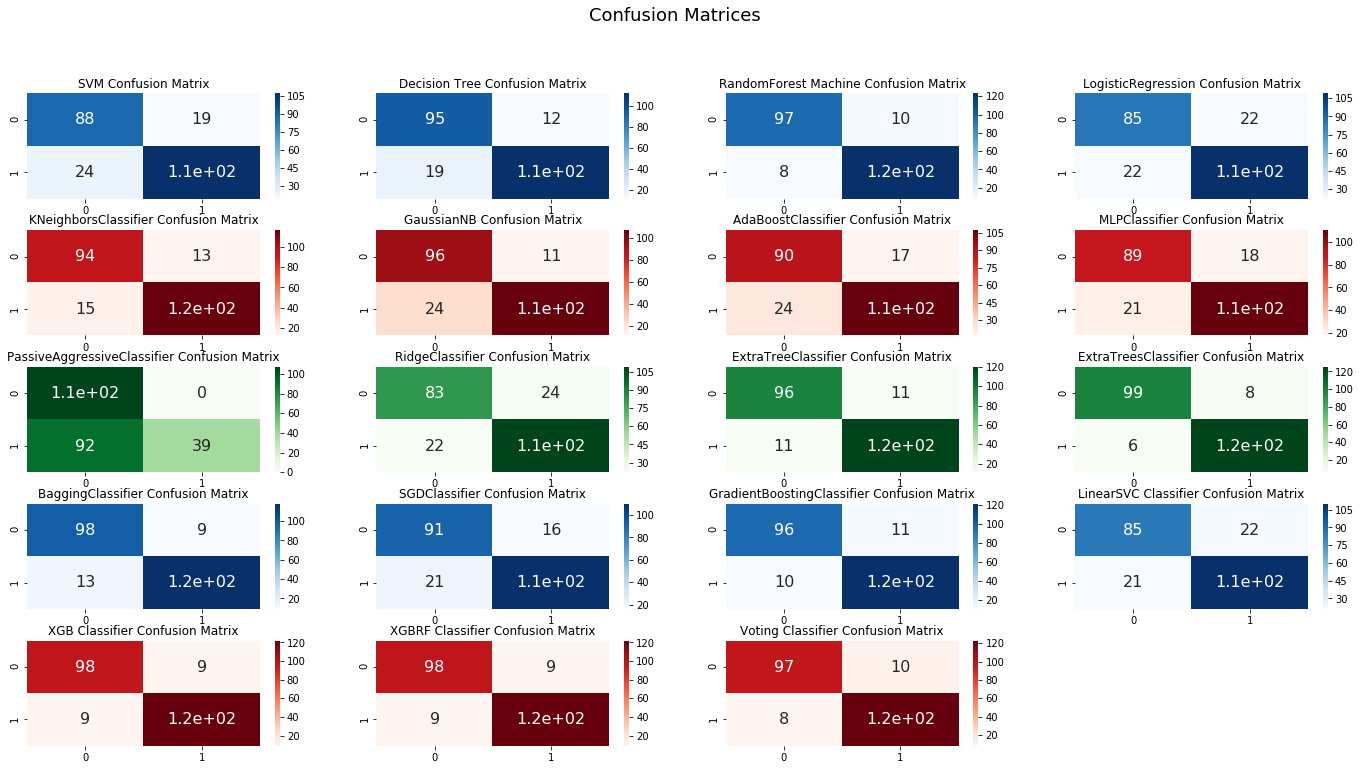

In [54]:
#from sklearn import cross_validation
from sklearn.model_selection import cross_val_score, cross_validate
fig = plt.figure(1)
#ax = plt.subplot(5,5,i+1)
plt.figure(figsize=(24,12))
#N = 6
#fig, axes = plt.subplots(nrows = N)
plt.suptitle("Confusion Matrices",fontsize=18)
plt.subplots_adjust(wspace = 0.2, hspace= 0.3)

plt.subplot(541)
plt.title("SVM Confusion Matrix")
sns.heatmap(cm_svm,cmap="Blues",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(542)
plt.title("Decision Tree Confusion Matrix")
sns.heatmap(cm_dtc,cmap="Blues",cbar=True,annot=True, annot_kws={"size": 16})

plt.subplot(543)
plt.title("RandomForest Machine Confusion Matrix")
sns.heatmap(cm_rf,cmap="Blues",cbar=True,annot=True, annot_kws={"size": 16})

plt.subplot(544)
plt.title("LogisticRegression Confusion Matrix")
sns.heatmap(cm_lr,cmap="Blues",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(545)
plt.title("KNeighborsClassifier Confusion Matrix")
sns.heatmap(cm_knn,cmap="Reds",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(546)
plt.title("GaussianNB Confusion Matrix")
sns.heatmap(cm_gnb,cmap="Reds",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(547)
plt.title("AdaBoostClassifier Confusion Matrix")
sns.heatmap(cm_adb,cmap="Reds",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(548)
plt.title("MLPClassifier Confusion Matrix")
sns.heatmap(cm_mpl,cmap="Reds",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(549)
plt.title("PassiveAggressiveClassifier Confusion Matrix")
sns.heatmap(cm_pac,cmap="Greens",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,10)
plt.title("RidgeClassifier Confusion Matrix")
sns.heatmap(cm_rc,cmap="Greens",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,11)
plt.title("ExtraTreeClassifier Confusion Matrix")
sns.heatmap(cm_tc,cmap="Greens",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,12)
plt.title("ExtraTreesClassifier Confusion Matrix")
sns.heatmap(cm_etc,cmap="Greens",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,13)
plt.title("BaggingClassifier Confusion Matrix")
sns.heatmap(cm_bc,cmap="Blues",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,14)
plt.title("SGDClassifier Confusion Matrix")
sns.heatmap(cm_sgd,cmap="Blues",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,15)
plt.title("GradientBoostingClassifier Confusion Matrix")
sns.heatmap(cm_gb,cmap="Blues",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,16)
plt.title("LinearSVC Classifier Confusion Matrix")
sns.heatmap(cm_lsvc,cmap="Blues",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,17)
plt.title("XGB Classifier Confusion Matrix")
sns.heatmap(cm_xgb, cmap="Reds",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,18)
plt.title("XGBRF Classifier Confusion Matrix")
sns.heatmap(cm_xgbrf, cmap="Reds",cbar=True, annot=True,annot_kws={"size": 16})

plt.subplot(5,4,19)
plt.title("Voting Classifier Confusion Matrix")
sns.heatmap(cm_vc,cmap="Reds",cbar=True, annot=True,annot_kws={"size": 16})

In [37]:
import matplotlib.pyplot as plt
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
 
# generate 2 class dataset
#X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
# split into train/test sets
#train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=2)
# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(test_y))]
# fit a model

model1 = AdaBoostClassifier(n_estimators=100, learning_rate=10, algorithm='SAMME', random_state=None)
model2 = BaggingClassifier(max_features=11, max_samples=11, n_estimators=10)
model3 = DecisionTreeClassifier(criterion='gini',splitter='random',max_depth=None, min_samples_leaf=2, min_samples_split=5, max_features=None)
model4 = ExtraTreesClassifier(n_estimators=100, criterion='entropy', max_depth=None, min_samples_split=2, min_samples_leaf=2, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=False, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None)
model5 = GradientBoostingClassifier(loss='exponential', learning_rate=0.5, n_estimators=50, subsample=1.0, criterion='squared_error', min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_depth=5, min_impurity_decrease=0.0, init=None, random_state=1, max_features='sqrt', verbose=0, max_leaf_nodes=None, warm_start=False, validation_fraction=0.5, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)
model6 = GaussianNB(var_smoothing=1e-09)
model7 = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='kd_tree', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)
#model8 = LogisticRegression(C=109.85411419875572, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100, multi_class='auto', n_jobs=None, penalty='l2', random_state=None, solver='newton-cg', tol=0.001, verbose=0, warm_start=False)
#model9 = LinearSVC(tol=0.0001, C=1.0, multi_class='crammer_singer', fit_intercept=True, intercept_scaling=1, class_weight=None, verbose=0, random_state=None, max_iter=500)
model10 = MLPClassifier(hidden_layer_sizes=(100,), activation='logistic', solver='lbfgs', alpha=0.0001, batch_size='auto', learning_rate='invscaling', learning_rate_init=0.001, power_t=0.5, max_iter=500, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=20000)
#model11 = PassiveAggressiveClassifier(C=0.5, fit_intercept=True, max_iter=1000, tol=1e-3, early_stopping=False, validation_fraction=0.1, n_iter_no_change=2, shuffle=True, verbose=0, loss='hinge', n_jobs=None, random_state=None, warm_start=False, class_weight='balanced', average=False)
#model12 = RidgeClassifier(alpha=0.5, fit_intercept=True, copy_X=True, max_iter=None, tol=0.001, class_weight='balanced', solver='cholesky', positive=False, random_state=None)
model13 = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', oob_score=True, random_state=42, n_jobs=-1)
#model14 = SGDClassifier(loss='squared_hinge', penalty='l1', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001, shuffle=True, verbose=0, epsilon=0.1, n_jobs=None, random_state=None, learning_rate='optimal', eta0=0.0, power_t=0.6, early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, class_weight=None, warm_start=False, average=False)
#model15 = SVC(C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight='balanced', verbose=False, max_iter=-1, decision_function_shape='ovo', break_ties=False, random_state=None)
model16 = ExtraTreeClassifier(max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, random_state=None, ccp_alpha=0.0)
model17 = XGBClassifier(learning_rate =0.1, n_estimators=50, max_depth=3, min_child_weight=5, gamma=0, subsample=0.8, colsample_bytree=0.8, reg_lambda=1, objective= 'binary:logistic', nthread=6, scale_pos_weight=1, seed=50)
model18 = xgbrf = XGBRFClassifier(n_estimators=200, max_depth=5, subsample=0.5, colsample_bytree=0.5, random_state=42)
#model19 = make_pipeline( StandardScaler(), NuSVC(nu=0.1, kernel='rbf', random_state=42))
model20 = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42, boosing_type='gbdt', force_row_wise=True, verbosity=-1)
model21 = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, loss_function='Logloss', eval_metric='Accuracy', random_seed=42, verbose=False)



#fit the model
model1.fit(train_X, train_y)
model2.fit(train_X, train_y)
model3.fit(train_X, train_y)
model4.fit(train_X, train_y)
model5.fit(train_X, train_y)
model6.fit(train_X, train_y)
model7.fit(train_X, train_y)
#model8.fit(train_X, train_y)
#model9.fit(train_X, train_y)
model10.fit(train_X, train_y)
#model11.fit(train_X, train_y)
#model12.fit(train_X, train_y)
model13.fit(train_X, train_y)
#model14.fit(train_X, train_y)
#model15.fit(train_X, train_y)
model16.fit(train_X, train_y)
model17.fit(train_X, train_y)
model18.fit(train_X, train_y)
#model19.fit(train_X, train_y)
model20.fit(train_X, train_y)
model21.fit(train_X, train_y)

# predict probabilities
lr_probs1 = model1.predict_proba(test_X)
lr_probs2 = model2.predict_proba(test_X)
lr_probs3 = model3.predict_proba(test_X)
lr_probs4 = model4.predict_proba(test_X)
lr_probs5 = model5.predict_proba(test_X)
lr_probs6 = model6.predict_proba(test_X)
lr_probs7 = model7.predict_proba(test_X)
#lr_probs8 = model8.predict_proba(test_X)
#lr_probs9 = model9.predict_proba(test_X)
lr_probs10 = model10.predict_proba(test_X)
#lr_probs11 = model11.predict_proba(test_X)
#lr_probs12 = model12.predict_proba(test_X)
lr_probs13 = model13.predict_proba(test_X)
#lr_probs14 = model14.predict_proba(test_X)
#lr_probs15 = model15.predict_proba(test_X)
lr_probs16 = model16.predict_proba(test_X)
lr_probs17 = model17.predict_proba(test_X)
lr_probs18 = model18.predict_proba(test_X)
#lr_probs19 = model19.predict_proba(test_X)
lr_probs20 = model20.predict_proba(test_X)
lr_probs21 = model21.predict_proba(test_X)

# keep probabilities for the positive outcome only
lr_probs1 = lr_probs1[:, 1]
lr_probs2 = lr_probs2[:, 1]
lr_probs3 = lr_probs3[:, 1]
lr_probs4 = lr_probs4[:, 1]
lr_probs5 = lr_probs5[:, 1]
lr_probs6 = lr_probs6[:, 1]
lr_probs7 = lr_probs7[:, 1]
#lr_probs8 = lr_probs8[:, 1]
#lr_probs9 = lr_probs9[:, 1]
lr_probs10 = lr_probs10[:, 1]
#lr_probs11 = lr_probs11[:, 1]
#lr_probs12 = lr_probs12[:, 1]
lr_probs13 = lr_probs13[:, 1]
#lr_probs14 = lr_probs14[:, 1]
#lr_probs15 = lr_probs15[:, 1]
lr_probs16 = lr_probs16[:, 1]
lr_probs17 = lr_probs17[:, 1]
lr_probs18 = lr_probs18[:, 1]
#lr_probs19 = lr_probs19[:, 1]
lr_probs20 = lr_probs20[:, 1]
lr_probs21 = lr_probs21[:, 1]

# calculate scores
ns_auc = roc_auc_score(test_y, ns_probs)
lr_auc1 = roc_auc_score(test_y, lr_probs1)
lr_auc2 = roc_auc_score(test_y, lr_probs2)
lr_auc3 = roc_auc_score(test_y, lr_probs3)
lr_auc4 = roc_auc_score(test_y, lr_probs4)
lr_auc5 = roc_auc_score(test_y, lr_probs5)
lr_auc6 = roc_auc_score(test_y, lr_probs6)
lr_auc7 = roc_auc_score(test_y, lr_probs7)
#lr_auc8 = roc_auc_score(test_y, lr_probs8)
#lr_auc9 = roc_auc_score(test_y, lr_probs9)
lr_auc10 = roc_auc_score(test_y, lr_probs10)
#lr_auc11 = roc_auc_score(test_y, lr_probs11)
#lr_auc12 = roc_auc_score(test_y, lr_probs12)
lr_auc13 = roc_auc_score(test_y, lr_probs13)
#lr_auc14 = roc_auc_score(test_y, lr_probs14)
#lr_auc15 = roc_auc_score(test_y, lr_probs15)
lr_auc16 = roc_auc_score(test_y, lr_probs16)
lr_auc17 = roc_auc_score(test_y, lr_probs17)
lr_auc18 = roc_auc_score(test_y, lr_probs18)
#lr_auc19 = roc_auc_score(test_y, lr_probs19)
lr_auc20 = roc_auc_score(test_y, lr_probs20)
lr_auc21 = roc_auc_score(test_y, lr_probs21)

# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('ADB: ROC AUC=%.3f' % (lr_auc1))
print('BC: ROC AUC=%.3f' % (lr_auc2))
print('DT: ROC AUC=%.3f' % (lr_auc3))
print('ETC: ROC AUC=%.3f' % (lr_auc4))
print('GB: ROC AUC=%.3f' % (lr_auc5))
print('GNB: ROC AUC=%.3f' % (lr_auc6))
print('KNN: ROC AUC=%.3f' % (lr_auc7))
#print('LR: ROC AUC=%.3f' % (lr_auc8))
#print('LSVC: ROC AUC=%.3f' % (lr_auc9))
print('MPL: ROC AUC=%.3f' % (lr_auc10))
#print('PAC: ROC AUC=%.3f' % (lr_auc11))
#print('RC: ROC AUC=%.3f' % (lr_auc12))
print('RF: ROC AUC=%.3f' % (lr_auc13))
#print('SGD: ROC AUC=%.3f' % (lr_auc14))
#print('SVC: ROC AUC=%.3f' % (lr_auc15))
print('TC: ROC AUC=%.3f' % (lr_auc16))
print('XGB: ROC AUC=%.3f' % (lr_auc17))
print('XGBRF: ROC AUC=%.3f' % (lr_auc18))
#print('NuSVC: ROC AUC=%.3f' % (lr_auc19))
print('LGBM: ROC AUC=%.3f' % (lr_auc20))
print('CB: ROC AUC=%.3f' % (lr_auc21))

# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(test_y, ns_probs)
lr_fpr1, lr_tpr1, _ = roc_curve(test_y, lr_probs1)
lr_fpr2, lr_tpr2, _ = roc_curve(test_y, lr_probs2)
lr_fpr3, lr_tpr3, _ = roc_curve(test_y, lr_probs3)
lr_fpr4, lr_tpr4, _ = roc_curve(test_y, lr_probs4)
lr_fpr5, lr_tpr5, _ = roc_curve(test_y, lr_probs5)
lr_fpr6, lr_tpr6, _ = roc_curve(test_y, lr_probs6)
lr_fpr7, lr_tpr7, _ = roc_curve(test_y, lr_probs7)
#lr_fpr8, lr_tpr8, _ = roc_curve(test_y, lr_probs8)
#lr_fpr9, lr_tpr9, _ = roc_curve(test_y, lr_probs9)
lr_fpr10, lr_tpr10, _ = roc_curve(test_y, lr_probs10)
#lr_fpr11, lr_tpr11, _ = roc_curve(test_y, lr_probs11)
#lr_fpr12, lr_tpr12, _ = roc_curve(test_y, lr_probs12)
lr_fpr13, lr_tpr13, _ = roc_curve(test_y, lr_probs13)
#lr_fpr14, lr_tpr14, _ = roc_curve(test_y, lr_probs14)
#lr_fpr15, lr_tpr15, _ = roc_curve(test_y, lr_probs15)
lr_fpr16, lr_tpr16, _ = roc_curve(test_y, lr_probs16)
lr_fpr17, lr_tpr17, _ = roc_curve(test_y, lr_probs17)
lr_fpr18, lr_tpr18, _ = roc_curve(test_y, lr_probs18)
#lr_fpr19, lr_tpr19, _ = roc_curve(test_y, lr_probs19)
lr_fpr20, lr_tpr20, _ = roc_curve(test_y, lr_probs20)
lr_fpr21, lr_tpr21, _ = roc_curve(test_y, lr_probs21)

# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--')
plt.plot(lr_fpr1, lr_tpr1, label='ADB')
plt.plot(lr_fpr2, lr_tpr2, label='BC')
plt.plot(lr_fpr3, lr_tpr3, label='DT')
plt.plot(lr_fpr4, lr_tpr4, label='ETC')
plt.plot(lr_fpr5, lr_tpr5, label='GB')
plt.plot(lr_fpr6, lr_tpr6, label='GNB')
plt.plot(lr_fpr7, lr_tpr7, label='KNN')
#plt.plot(lr_fpr8, lr_tpr8, label='LR')
#plt.plot(lr_fpr9, lr_tpr9, label='LSVC')
plt.plot(lr_fpr10, lr_tpr10, label='MPL')
#plt.plot(lr_fpr11, lr_tpr11, label='PAC')
#plt.plot(lr_fpr12, lr_tpr12, label='RC')
plt.plot(lr_fpr13, lr_tpr13, label='RF')
#plt.plot(lr_fpr14, lr_tpr14, label='SGD')
#plt.plot(lr_fpr15, lr_tpr15, label='SVC')
plt.plot(lr_fpr16, lr_tpr16, label='TC')
plt.plot(lr_fpr17, lr_tpr17, label='XGB')
plt.plot(lr_fpr18, lr_tpr18, label='XGBRF')
#plt.plot(lr_fpr19, lr_tpr19, label='NuSVC')
plt.plot(lr_fpr20, lr_tpr20, label='LGBM')
plt.plot(lr_fpr21, lr_tpr21, label='CB')


#plt.fill_between(lr_fpr, lr_tpr, facecolor='lightblue', alpha=0.7)
plt.text(0.80, 0.80, 'AUC = %0.3f' % lr_auc1, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.74, 'AUC = %0.3f' % lr_auc2, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.68, 'AUC = %0.3f' % lr_auc3, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.62, 'AUC = %0.3f' % lr_auc4, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.56, 'AUC = %0.3f' % lr_auc5, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.50, 'AUC = %0.3f' % lr_auc6, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.44, 'AUC = %0.3f' % lr_auc7, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.06, 'AUC = %0.3f' % lr_auc8, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.00, 'AUC = %0.3f' % lr_auc9, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.37, 'AUC = %0.3f' % lr_auc10, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.43, 'AUC = %0.3f' % lr_auc11, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.38, 'AUC = %0.3f' % lr_auc12, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.315, 'AUC = %0.3f' % lr_auc13, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.25, 'AUC = %0.3f' % lr_auc14, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.18, 'AUC = %0.3f' % lr_auc15, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.25, 'AUC = %0.3f' % lr_auc16, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.185, 'AUC = %0.3f' % lr_auc17, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.125, 'AUC = %0.3f' % lr_auc18, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.12, 'AUC = %0.3f' % lr_auc19, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.065, 'AUC = %0.3f' % lr_auc20, ha='right', fontsize=8, weight='light')
plt.text(0.80, 0.00, 'AUC = %0.3f' % lr_auc21, ha='right', fontsize=8, weight='light')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

ValueError: max_features must be <= n_features

No Skill: ROC AUC=0.500
ADB: ROC AUC=0.769
BC: ROC AUC=0.797
DT: ROC AUC=0.906
ETC: ROC AUC=0.939
GB: ROC AUC=0.953
GNB: ROC AUC=0.899
KNN: ROC AUC=0.751
LR: ROC AUC=0.911
LSVC: ROC AUC=0.906
MPL: ROC AUC=0.895
PAC: ROC AUC=0.826
RC: ROC AUC=0.909
RF: ROC AUC=0.954
SGD: ROC AUC=0.872
SVC: ROC AUC=0.801
TC: ROC AUC=0.876
XGB: ROC AUC=0.923
XGBRF: ROC AUC=0.926
LGBM: ROC AUC=0.953
CB: ROC AUC=0.943


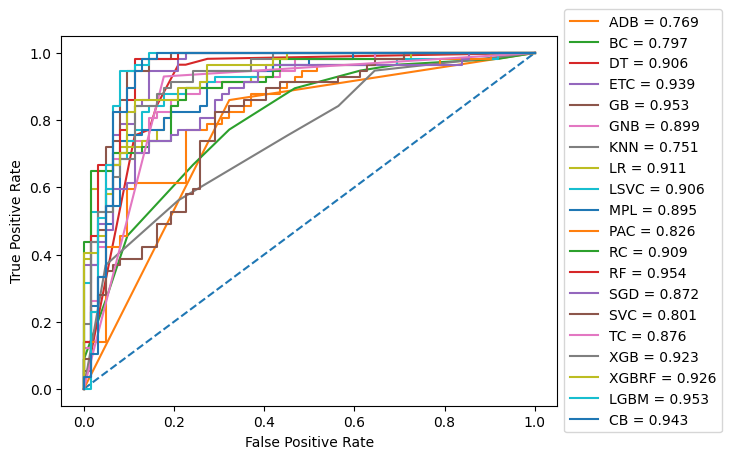

In [40]:
import matplotlib.pyplot as plt
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
 
# generate 2 class dataset
#X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
# split into train/test sets
#train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=2)
# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(test_y))]
# fit a model

model1 = AdaBoostClassifier(n_estimators=100, learning_rate=10, algorithm='SAMME', random_state=None)
model2 = BaggingClassifier(max_features=9, max_samples=11, n_estimators=10)
model3 = DecisionTreeClassifier(criterion='gini',splitter='random',max_depth=None, min_samples_leaf=2, min_samples_split=5, max_features=None)
model4 = ExtraTreesClassifier(n_estimators=100, criterion='entropy', max_depth=None, min_samples_split=2, min_samples_leaf=2, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=False, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None)
model5 = GradientBoostingClassifier(loss='exponential', learning_rate=0.5, n_estimators=50, subsample=1.0, criterion='squared_error', min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_depth=5, min_impurity_decrease=0.0, init=None, random_state=1, max_features='sqrt', verbose=0, max_leaf_nodes=None, warm_start=False, validation_fraction=0.5, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)
model6 = GaussianNB(var_smoothing=1e-09)
model7 = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='kd_tree', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)
model8 = LogisticRegression(C=109.85411419875572, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100, multi_class='auto', n_jobs=None, penalty='l2', random_state=None, solver='newton-cg', tol=0.001, verbose=0, warm_start=False)
model9 = LinearSVC(tol=0.0001, C=1.0, multi_class='crammer_singer', fit_intercept=True, intercept_scaling=1, class_weight=None, verbose=0, random_state=None, max_iter=500)
model10 = MLPClassifier(hidden_layer_sizes=(100,), activation='logistic', solver='lbfgs', alpha=0.0001, batch_size='auto', learning_rate='invscaling', learning_rate_init=0.001, power_t=0.5, max_iter=500, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=20000)
model11 = PassiveAggressiveClassifier(C=0.5, fit_intercept=True, max_iter=1000, tol=1e-3, early_stopping=False, validation_fraction=0.1, n_iter_no_change=2, shuffle=True, verbose=0, loss='hinge', n_jobs=None, random_state=None, warm_start=False, class_weight='balanced', average=False)
model12 = RidgeClassifier(alpha=0.5, fit_intercept=True, copy_X=True, max_iter=None, tol=0.001, class_weight='balanced', solver='cholesky', positive=False, random_state=None)
model13 = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', oob_score=True, random_state=42, n_jobs=-1)
model14 = SGDClassifier(loss='squared_hinge', penalty='l1', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001, shuffle=True, verbose=0, epsilon=0.1, n_jobs=None, random_state=None, learning_rate='optimal', eta0=0.0, power_t=0.6, early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, class_weight=None, warm_start=False, average=False)
model15 = SVC(C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=True, tol=0.001, cache_size=200, class_weight='balanced', verbose=False, max_iter=-1, decision_function_shape='ovo', break_ties=False, random_state=None)
model16 = ExtraTreeClassifier(max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, random_state=None, ccp_alpha=0.0)
model17 = XGBClassifier(learning_rate =0.1, n_estimators=50, max_depth=3, min_child_weight=5, gamma=0, subsample=0.8, colsample_bytree=0.8, reg_lambda=1, objective= 'binary:logistic', nthread=6, scale_pos_weight=1, seed=50)
model18 = xgbrf = XGBRFClassifier(n_estimators=200, max_depth=5, subsample=0.5, colsample_bytree=0.5, random_state=42)
#model19 = make_pipeline( StandardScaler(), NuSVC(nu=0.1, kernel='rbf', random_state=42))
model20 = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42, boosing_type='gbdt', force_row_wise=True, verbosity=-1)
model21 = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, loss_function='Logloss', eval_metric='Accuracy', random_seed=42, verbose=False)

# Wrap LSVC with calibration to enable predict_proba
cal_model9 = CalibratedClassifierCV(model9)
cal_model11 = CalibratedClassifierCV(model11, method='sigmoid', cv=5)
cal_model12 = CalibratedClassifierCV(model12, cv=5)
cal_model14 = CalibratedClassifierCV(model14, cv=5)

#fit the model
model1.fit(train_X, train_y)
model2.fit(train_X, train_y)
model3.fit(train_X, train_y)
model4.fit(train_X, train_y)
model5.fit(train_X, train_y)
model6.fit(train_X, train_y)
model7.fit(train_X, train_y)
model8.fit(train_X, train_y)
cal_model9.fit(train_X, train_y)
model10.fit(train_X, train_y)
cal_model11.fit(train_X, train_y)
cal_model12.fit(train_X, train_y)
model13.fit(train_X, train_y)
cal_model14.fit(train_X, train_y)
model15.fit(train_X, train_y)
model16.fit(train_X, train_y)
model17.fit(train_X, train_y)
model18.fit(train_X, train_y)
#model19.fit(train_X, train_y)
model20.fit(train_X, train_y)
model21.fit(train_X, train_y)

# predict probabilities
lr_probs1 = model1.predict_proba(test_X)
lr_probs2 = model2.predict_proba(test_X)
lr_probs3 = model3.predict_proba(test_X)
lr_probs4 = model4.predict_proba(test_X)
lr_probs5 = model5.predict_proba(test_X)
lr_probs6 = model6.predict_proba(test_X)
lr_probs7 = model7.predict_proba(test_X)
lr_probs8 = model8.predict_proba(test_X)
lr_probs9 = cal_model9.predict_proba(test_X)
lr_probs10 = model10.predict_proba(test_X)
lr_probs11 = cal_model11.predict_proba(test_X)
lr_probs12 = cal_model12.predict_proba(test_X)
lr_probs13 = model13.predict_proba(test_X)
lr_probs14 = cal_model14.predict_proba(test_X)
lr_probs15 = model15.predict_proba(test_X)
lr_probs16 = model16.predict_proba(test_X)
lr_probs17 = model17.predict_proba(test_X)
lr_probs18 = model18.predict_proba(test_X)
#lr_probs19 = model19.predict_proba(test_X)
lr_probs20 = model20.predict_proba(test_X)
lr_probs21 = model21.predict_proba(test_X)

# keep probabilities for the positive outcome only
lr_probs1 = lr_probs1[:, 1]
lr_probs2 = lr_probs2[:, 1]
lr_probs3 = lr_probs3[:, 1]
lr_probs4 = lr_probs4[:, 1]
lr_probs5 = lr_probs5[:, 1]
lr_probs6 = lr_probs6[:, 1]
lr_probs7 = lr_probs7[:, 1]
lr_probs8 = lr_probs8[:, 1]
lr_probs9 = lr_probs9[:, 1]
lr_probs10 = lr_probs10[:, 1]
lr_probs11 = lr_probs11[:, 1]
lr_probs12 = lr_probs12[:, 1]
lr_probs13 = lr_probs13[:, 1]
lr_probs14 = lr_probs14[:, 1]
lr_probs15 = lr_probs15[:, 1]
lr_probs16 = lr_probs16[:, 1]
lr_probs17 = lr_probs17[:, 1]
lr_probs18 = lr_probs18[:, 1]
#lr_probs19 = lr_probs19[:, 1]
lr_probs20 = lr_probs20[:, 1]
lr_probs21 = lr_probs21[:, 1]

# calculate scores
ns_auc = roc_auc_score(test_y, ns_probs)
lr_auc1 = roc_auc_score(test_y, lr_probs1)
lr_auc2 = roc_auc_score(test_y, lr_probs2)
lr_auc3 = roc_auc_score(test_y, lr_probs3)
lr_auc4 = roc_auc_score(test_y, lr_probs4)
lr_auc5 = roc_auc_score(test_y, lr_probs5)
lr_auc6 = roc_auc_score(test_y, lr_probs6)
lr_auc7 = roc_auc_score(test_y, lr_probs7)
lr_auc8 = roc_auc_score(test_y, lr_probs8)
lr_auc9 = roc_auc_score(test_y, lr_probs9)
lr_auc10 = roc_auc_score(test_y, lr_probs10)
lr_auc11 = roc_auc_score(test_y, lr_probs11)
lr_auc12 = roc_auc_score(test_y, lr_probs12)
lr_auc13 = roc_auc_score(test_y, lr_probs13)
lr_auc14 = roc_auc_score(test_y, lr_probs14)
lr_auc15 = roc_auc_score(test_y, lr_probs15)
lr_auc16 = roc_auc_score(test_y, lr_probs16)
lr_auc17 = roc_auc_score(test_y, lr_probs17)
lr_auc18 = roc_auc_score(test_y, lr_probs18)
#lr_auc19 = roc_auc_score(test_y, lr_probs19)
lr_auc20 = roc_auc_score(test_y, lr_probs20)
lr_auc21 = roc_auc_score(test_y, lr_probs21)

# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('ADB: ROC AUC=%.3f' % (lr_auc1))
print('BC: ROC AUC=%.3f' % (lr_auc2))
print('DT: ROC AUC=%.3f' % (lr_auc3))
print('ETC: ROC AUC=%.3f' % (lr_auc4))
print('GB: ROC AUC=%.3f' % (lr_auc5))
print('GNB: ROC AUC=%.3f' % (lr_auc6))
print('KNN: ROC AUC=%.3f' % (lr_auc7))
print('LR: ROC AUC=%.3f' % (lr_auc8))
print('LSVC: ROC AUC=%.3f' % (lr_auc9))
print('MPL: ROC AUC=%.3f' % (lr_auc10))
print('PAC: ROC AUC=%.3f' % (lr_auc11))
print('RC: ROC AUC=%.3f' % (lr_auc12))
print('RF: ROC AUC=%.3f' % (lr_auc13))
print('SGD: ROC AUC=%.3f' % (lr_auc14))
print('SVC: ROC AUC=%.3f' % (lr_auc15))
print('TC: ROC AUC=%.3f' % (lr_auc16))
print('XGB: ROC AUC=%.3f' % (lr_auc17))
print('XGBRF: ROC AUC=%.3f' % (lr_auc18))
#print('NuSVC: ROC AUC=%.3f' % (lr_auc19))
print('LGBM: ROC AUC=%.3f' % (lr_auc20))
print('CB: ROC AUC=%.3f' % (lr_auc21))

# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(test_y, ns_probs)
lr_fpr1, lr_tpr1, _ = roc_curve(test_y, lr_probs1)
lr_fpr2, lr_tpr2, _ = roc_curve(test_y, lr_probs2)
lr_fpr3, lr_tpr3, _ = roc_curve(test_y, lr_probs3)
lr_fpr4, lr_tpr4, _ = roc_curve(test_y, lr_probs4)
lr_fpr5, lr_tpr5, _ = roc_curve(test_y, lr_probs5)
lr_fpr6, lr_tpr6, _ = roc_curve(test_y, lr_probs6)
lr_fpr7, lr_tpr7, _ = roc_curve(test_y, lr_probs7)
lr_fpr8, lr_tpr8, _ = roc_curve(test_y, lr_probs8)
lr_fpr9, lr_tpr9, _ = roc_curve(test_y, lr_probs9)
lr_fpr10, lr_tpr10, _ = roc_curve(test_y, lr_probs10)
lr_fpr11, lr_tpr11, _ = roc_curve(test_y, lr_probs11)
lr_fpr12, lr_tpr12, _ = roc_curve(test_y, lr_probs12)
lr_fpr13, lr_tpr13, _ = roc_curve(test_y, lr_probs13)
lr_fpr14, lr_tpr14, _ = roc_curve(test_y, lr_probs14)
lr_fpr15, lr_tpr15, _ = roc_curve(test_y, lr_probs15)
lr_fpr16, lr_tpr16, _ = roc_curve(test_y, lr_probs16)
lr_fpr17, lr_tpr17, _ = roc_curve(test_y, lr_probs17)
lr_fpr18, lr_tpr18, _ = roc_curve(test_y, lr_probs18)
#lr_fpr19, lr_tpr19, _ = roc_curve(test_y, lr_probs19)
lr_fpr20, lr_tpr20, _ = roc_curve(test_y, lr_probs20)
lr_fpr21, lr_tpr21, _ = roc_curve(test_y, lr_probs21)

# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--')
plt.plot(lr_fpr1, lr_tpr1, label=f'ADB = {lr_auc1:.3f}')
plt.plot(lr_fpr2, lr_tpr2, label=f'BC = {lr_auc2:.3f}')
plt.plot(lr_fpr3, lr_tpr3, label=f'DT = {lr_auc3:.3f}')
plt.plot(lr_fpr4, lr_tpr4,label=f'ETC = {lr_auc4:.3f}')
plt.plot(lr_fpr5, lr_tpr5, label=f'GB = {lr_auc5:.3f}')
plt.plot(lr_fpr6, lr_tpr6, label=f'GNB = {lr_auc6:.3f}')
plt.plot(lr_fpr7, lr_tpr7, label=f'KNN = {lr_auc7:.3f}')
plt.plot(lr_fpr8, lr_tpr8, label=f'LR = {lr_auc8:.3f}')
plt.plot(lr_fpr9, lr_tpr9, label=f'LSVC = {lr_auc9:.3f}')
plt.plot(lr_fpr10, lr_tpr10, label=f'MPL = {lr_auc10:.3f}')
plt.plot(lr_fpr11, lr_tpr11, label=f'PAC = {lr_auc11:.3f}')
plt.plot(lr_fpr12, lr_tpr12, label=f'RC = {lr_auc12:.3f}')
plt.plot(lr_fpr13, lr_tpr13, label=f'RF = {lr_auc13:.3f}')
plt.plot(lr_fpr14, lr_tpr14, label=f'SGD = {lr_auc14:.3f}')
plt.plot(lr_fpr15, lr_tpr15, label=f'SVC = {lr_auc15:.3f}')
plt.plot(lr_fpr16, lr_tpr16, label=f'TC = {lr_auc16:.3f}')
plt.plot(lr_fpr17, lr_tpr17, label=f'XGB = {lr_auc17:.3f}')
plt.plot(lr_fpr18, lr_tpr18, label=f'XGBRF = {lr_auc18:.3f}')
#plt.plot(lr_fpr19, lr_tpr19, label='NuSVC')
plt.plot(lr_fpr20, lr_tpr20, label=f'LGBM = {lr_auc20:.3f}')
plt.plot(lr_fpr21, lr_tpr21, label=f'CB = {lr_auc21:.3f}')
#plt.text(1.2, 0.00, label='CB', ha='right')


#plt.fill_between(lr_fpr, lr_tpr, facecolor='lightblue', alpha=0.7)
#plt.figure(figsize=(18, 16))
#plt.text(1.0, 0.99, 'ADB = %0.2f' % lr_auc1, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.93, 'BC = %0.2f' % lr_auc2, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.87, 'DT = %0.2f' % lr_auc3, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.81, 'ETC = %0.2f' % lr_auc4, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.75, 'GB = %0.2f' % lr_auc5, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.68, 'GNB = %0.2f' % lr_auc6, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.62, 'KNN = %0.2f' % lr_auc7, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.56, 'LR = %0.2f' % lr_auc8, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.50, 'LSVC = %0.2f' % lr_auc9, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.435, 'MPL = %0.2f' % lr_auc10, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.43, 'AUC = %0.3f' % lr_auc11, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.38, 'AUC = %0.3f' % lr_auc12, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.37, 'RF = %0.2f' % lr_auc13, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.25, 'AUC = %0.3f' % lr_auc14, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.31, 'SVC = %0.2f' % lr_auc15, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.25, 'TC = %0.2f' % lr_auc16, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.19, 'XGB = %0.2f' % lr_auc17, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.125, 'XGBRF = %0.2f' % lr_auc18, ha='right', fontsize=8, weight='light')
#plt.text(0.80, 0.12, 'AUC = %0.3f' % lr_auc19, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.06, 'LGBM = %0.2f' % lr_auc20, ha='right', fontsize=8, weight='light')
#plt.text(1.0, 0.00, 'CB = %0.2f' % lr_auc21, ha='right', fontsize=8, weight='light')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
# show the plot
plt.show()